In [1]:
import pandas as pd

In [2]:
df_data = pd.read_csv("Clean_Dataset.csv")

In [3]:
df_data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
df_data["airline"].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [5]:
df_data["class"].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

## Preprocessing 
converting categorical data into numeric and binary

In [6]:
df_data = df_data.drop(columns=['Unnamed: 0','flight'], axis=1)

In [7]:
df_data['class'] = df_data['class'].apply(lambda x: 1 if x == "Business" else 0)

In [8]:
df_data.stops = pd.factorize(df_data.stops)[0]

In [9]:
df_data = df_data.join(pd.get_dummies(df_data.airline, prefix="airline", dtype=int)).drop('airline',axis=1)
df_data = df_data.join(pd.get_dummies(df_data.source_city, prefix="source", dtype=int)).drop('source_city',axis=1)
df_data = df_data.join(pd.get_dummies(df_data.destination_city, prefix="dest", dtype=int)).drop('destination_city',axis=1)
df_data = df_data.join(pd.get_dummies(df_data.departure_time, prefix="departure", dtype=int)).drop('departure_time',axis=1)
df_data = df_data.join(pd.get_dummies(df_data.arrival_time, prefix="arrival", dtype=int)).drop('arrival_time',axis=1)



In [10]:
df_data

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,departure_Evening,departure_Late_Night,departure_Morning,departure_Night,arrival_Afternoon,arrival_Early_Morning,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night
0,0,0,2.17,1,5953,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
1,0,0,2.33,1,5953,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0,0,2.17,1,5956,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,2.25,1,5955,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
4,0,0,2.33,1,5955,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
300149,1,1,10.42,49,77105,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
300150,1,1,13.83,49,79099,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
300151,1,1,10.00,49,81585,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


## Training Regression Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [12]:
X = df_data.drop('price', axis=1)
y = df_data.price

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)

In [14]:
reg = RandomForestRegressor(n_jobs=-1)
reg.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
reg.score(X_test,y_test)

0.98523684887856

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [21]:
y_pred = reg.predict(X_test)

print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
      

MAE 1082.6913869359296
MSE 7620713.306926201


Text(0.5, 1.0, 'Prediction vs Actual Price')

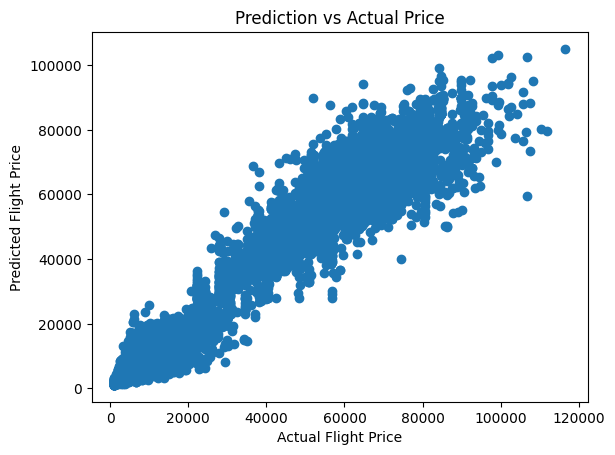

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Flight Price")
plt.ylabel("Predicted Flight Price")
plt.title("Prediction vs Actual Price")